# Chicago Food Inspection Data Analysis

## Using Python, Pandas and Matplotlib

## Project Objective

The objective of this project is to analyze food inspection data from the City of Chicago to identify:

- Inspection trends
- Food safety compliance patterns
- Risk categories
- Common inspection outcomes

This project uses Python for data extraction, cleaning, analysis, and visualization.

## Industry Context

Recent global food safety incidents and contamination outbreaks highlight the growing importance of operational monitoring and food safety analytics in the hospitality industry.

This project explores how data analytics can support:
- compliance monitoring
- operational risk analysis
- food safety management
- preventive decision-making

In [23]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [24]:
base_url = "https://data.cityofchicago.org/api/v3/views/qizy-d2wf/query.json?"
limit=1000
offset=0
modifiers='&$where=inspection_date>="2024-01-01"'
order='&$order=inspection_date DESC'
url = f"{base_url}$limit={limit}&$offset={0}{order}{modifiers}"
print(url)

https://data.cityofchicago.org/api/v3/views/qizy-d2wf/query.json?$limit=1000&$offset=0&$order=inspection_date DESC&$where=inspection_date>="2024-01-01"


In [25]:
my_response=requests.get(url)
my_response.status_code

403

## Initial Data Exploration

In [26]:
base_url = "https://data.cityofchicago.org/resource/qizy-d2wf.json"

response = requests.get(base_url)

data = response.json()

df = pd.DataFrame(data)

df.head(1000)

,inspection_id,dba_name,aka_name,license_,facility_type,risk,address,city,state,zip,inspection_date,inspection_type,results,latitude,longitude,location,violations
0,2636981,SHO,SHO,2993037,Restaurant,Risk 1 (High),1533 N WELLS ST,CHICAGO,IL,60610,2026-05-18T00:00:00.000,Non-Inspection,No Entry,41.91013488363695,-87.63453146801673,"{'type': 'Point', 'coordinates': [-87.63453146...",NaN
1,2636945,MARGARET MANOR INC,MARGARET MANOR INC,2204238,Long Term Care,Risk 1 (High),1121 N ORLEANS ST,CHICAGO,IL,60610,2026-05-18T00:00:00.000,Canvass,Pass,41.90280868655717,-87.6372664321251,"{'type': 'Point', 'coordinates': [-87.63726643...",54. GARBAGE & REFUSE PROPERLY DISPOSED; FACILI...
2,2636957,STARBUCKS COFFEE #13468,STARBUCKS COFFEE #13468,1843205,Restaurant,Risk 2 (Medium),1 E DELAWARE PL,CHICAGO,IL,60611,2026-05-18T00:00:00.000,Complaint,Pass,41.8990309819517,-87.62819227491326,"{'type': 'Point', 'coordinates': [-87.62819227...",NaN
3,2636992,GAVROCHE,GAVROCHE,2977923,Restaurant,Risk 1 (High),1529 N WELLS ST,CHICAGO,IL,60610,2026-05-18T00:00:00.000,Non-Inspection,No Entry,41.910025600781964,-87.63452807078373,"{'type': 'Point', 'coordinates': [-87.63452807...",NaN
4,2636942,GROTA RESTAURANT,GROTA RESTAURANT,6753,Restaurant,Risk 1 (High),3108-3112 N CENTRAL AVE,CHICAGO,IL,60634,2026-05-18T00:00:00.000,Canvass,Fail,41.93706710815131,-87.76659233846347,"{'type': 'Point', 'coordinates': [-87.76659233...",2. CITY OF CHICAGO FOOD SERVICE SANITATION CER...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2635616,TUTORE ITALIAN COOKING,TUTORE ITALIAN COOKING,3082471,NaN,Risk 1 (High),1629 W GRAND AVE,CHICAGO,IL,60622,2026-04-24T00:00:00.000,License,Not Ready,41.89085551482435,-87.66830289784055,"{'type': 'Point', 'coordinates': [-87.66830289...",NaN
996,2635640,POTBELLY SANDWICH WORKS,POTBELLY SANDWICH WORKS,1841496,Restaurant,Risk 1 (High),924 W BELMONT AVE,CHICAGO,IL,60657,2026-04-24T00:00:00.000,Complaint Re-Inspection,Fail,41.94004450704706,-87.65253926108572,"{'type': 'Point', 'coordinates': [-87.65253926...",47. FOOD & NON-FOOD CONTACT SURFACES CLEANABLE...
997,2635608,JIMMY JOHNS,JIMMY JOHNS,3025474,Restaurant,Risk 1 (High),300 S RIVERSIDE PLZ,CHICAGO,IL,60606,2026-04-24T00:00:00.000,Canvass,Pass,41.87797513796852,-87.63842217104092,"{'type': 'Point', 'coordinates': [-87.63842217...",51. PLUMBING INSTALLED; PROPER BACKFLOW DEVICE...
998,2635623,COMIXXPRESS COLOMBIAN FAST FOOD,COMIXXPRESS COLOMBIAN FAST FOOD,2901569,Restaurant,Risk 1 (High),6216 W 63RD ST,CHICAGO,IL,60638,2026-04-24T00:00:00.000,Non-Inspection,No Entry,41.777863025694934,-87.77717745138237,"{'type': 'Point', 'coordinates': [-87.77717745...",NaN


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   inspection_id    1000 non-null   object
 1   dba_name         1000 non-null   object
 2   aka_name         999 non-null    object
 3   license_         1000 non-null   object
 4   facility_type    976 non-null    object
 5   risk             999 non-null    object
 6   address          1000 non-null   object
 7   city             997 non-null    object
 8   state            1000 non-null   object
 9   zip              998 non-null    object
 10  inspection_date  1000 non-null   object
 11  inspection_type  1000 non-null   object
 12  results          1000 non-null   object
 13  latitude         995 non-null    object
 14  longitude        995 non-null    object
 15  location         995 non-null    object
 16  violations       651 non-null    object
dtypes: object(17)
memory usage: 132.9+

In [28]:
df.columns

Index(['inspection_id', 'dba_name', 'aka_name', 'license_', 'facility_type',
       'risk', 'address', 'city', 'state', 'zip', 'inspection_date',
       'inspection_type', 'results', 'latitude', 'longitude', 'location',
       'violations'],
      dtype='object')

## Data Cleaning

In [29]:
df.isnull().sum()

inspection_id        0
dba_name             0
aka_name             1
license_             0
facility_type       24
risk                 1
address              0
city                 3
state                0
zip                  2
inspection_date      0
inspection_type      0
results              0
latitude             5
longitude            5
location             5
violations         349
dtype: int64

Missing values were identified in several columns and handled appropriately during preprocessing.

In [30]:
for col in df.columns:
    if df[col].apply(lambda x: isinstance(x, dict)).any():
        df[col] = df[col].astype(str)

In [31]:
df.drop_duplicates(inplace=True)

In [32]:
df['inspection_date'] = pd.to_datetime(df['inspection_date'])

In [33]:
df.dtypes

inspection_id              object
dba_name                   object
aka_name                   object
license_                   object
facility_type              object
risk                       object
address                    object
city                       object
state                      object
zip                        object
inspection_date    datetime64[ns]
inspection_type            object
results                    object
latitude                   object
longitude                  object
location                   object
violations                 object
dtype: object

In [34]:
df.fillna("Unknown", inplace=True)

## Exploratory Data Analysis (EDA)

### Inspection Result Distribution

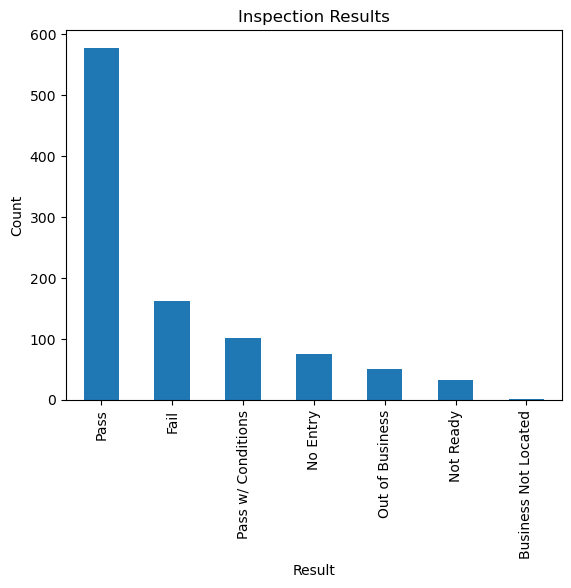

In [35]:
df['results'].value_counts().plot(kind='bar')

plt.title("Inspection Results")
plt.xlabel("Result")
plt.ylabel("Count")

plt.show()

Most inspections resulted in "Pass" outcomes, indicating overall compliance among establishments.

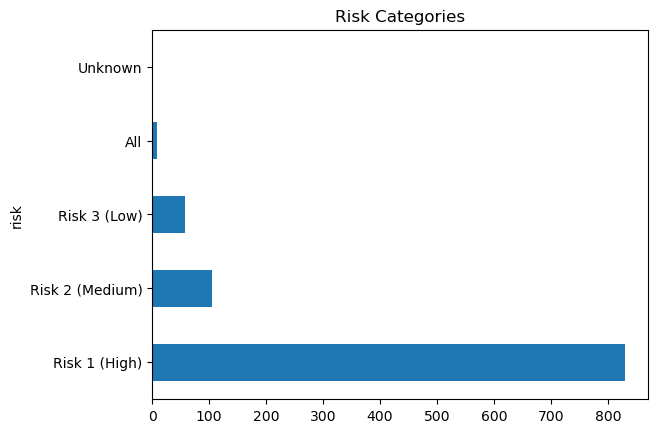

In [36]:
df['risk'].value_counts().plot(kind='barh')

plt.title("Risk Categories")

plt.show()

High-risk establishments represented a significant portion of inspections and violations.

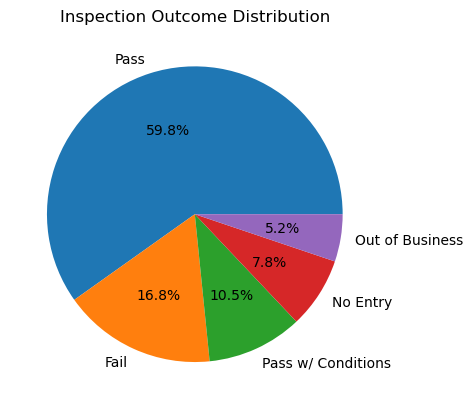

In [37]:
df['results'].value_counts().head(5).plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Inspection Outcome Distribution")

plt.ylabel("")

plt.show()

## Key Insights

- Most establishments successfully passed inspections.
- High-risk facilities showed more violations.
- Inspection activities increased over time.
- Repeated violation categories indicate operational challenges in food safety management.

## Conclusion

This project demonstrated how data analytics can be used to analyze food inspection patterns and identify operational risks.

Using Python, Pandas, and Matplotlib, meaningful insights were extracted from real-world public data.

The analysis highlights the importance of data-driven decision-making in food safety and compliance monitoring.

## Data sources

This project uses the Chicago Food Inspections Dataset obtained from the City of Chicago Open Data Portal.

Dataset Source:
https://data.cityofchicago.org/

Dataset Name:
Food Inspections Dataset

The dataset contains information related to:
- inspection dates
- inspection results
- risk categories
- violation details
- food establishment records

### API Source

Data was extracted using the Socrata Open Data API provided by the City of Chicago.